# Resultados — optimización de geometría y selección de actuadores (SenecaBot)

Visualiza la salida de `python -m geometry_opt.run_pipeline`. En la celda de **opciones** de abajo se elige si las
patas izquierda y derecha llevan el mismo motor y si se vuelve a correr el análisis (~1.5 min, CPU, sin GPU). Solo la sección 7 (sensibilidad al amortiguamiento) vuelve a correr
el lazo de dinámica inversa (~2 min).

Contenido: 1. resumen · 2. convergencia · 3. selección de motores · 4. punto de operación de cada motor · 4b. torques y velocidades vs límites ·
5. series de tiempo de torque · 6. estructura · 7. sensibilidad al amortiguamiento · 8. asimetría izquierda/derecha

In [1]:
# ============================== OPCIONES DEL ANÁLISIS ==============================
MISMOS_MOTORES_IZQ_DER = False   # True : cada par izquierda/derecha (FR=FL, BR=BL) lleva el MISMO motor;
                                 #        el par se dimensiona con el requerimiento mayor de los dos lados
                                 # False: cada articulación elige su motor por separado
CORRER_ANALISIS = True           # True : corre el pipeline completo con la opción de arriba (~1.5 min)
                                 # False: solo lee los resultados ya guardados de esa opción
# Cada opción guarda sus resultados en su propia carpeta (results/ o results/symmetric_motors/)
# y su propio reporte (results_summary.md o results_summary_symmetric.md): no se sobrescriben.

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# ubicar la carpeta que contiene geometry_opt/ (funciona abriendo el notebook desde cualquier sitio)
here = Path.cwd().resolve()
WS = next(p for p in [here, *here.parents] if (p / "geometry_opt" / "config.py").exists())
sys.path.insert(0, str(WS))
from geometry_opt import config as C, catalog as CAT, structural as ST
from geometry_opt.model_builder import JOINT_NAMES, LINK_NAMES

# --- aplicar opciones y (opcionalmente) correr el análisis ------------------------------------
import contextlib, io
from geometry_opt import run_pipeline
C.SYMMETRIC_MOTORS = MISMOS_MOTORES_IZQ_DER
RES = C.output_dir()
MODO = "mismo motor izquierda/derecha" if C.SYMMETRIC_MOTORS else "motor independiente por articulación"
if CORRER_ANALISIS or not (RES / "motors_v140_PLA.csv").exists():
    print(f"Corriendo el análisis ({MODO}) ...")
    log = io.StringIO()
    with contextlib.redirect_stdout(log):
        run_pipeline.main(["--symmetric"] if C.SYMMETRIC_MOTORS else [])
    print("\n".join(l.strip() for l in log.getvalue().splitlines()
                    if "final mass" in l or l.startswith("== 100M") or l.startswith("Written")))
print(f"Modo: {MODO}  ->  resultados en {RES.relative_to(WS)}")
POLICIES = {"v0218": "0.218 m/s", "v140": "1.40 m/s"}
MATERIALS = ["PLA", "PETG"]
LEGS = ["FR", "FL", "BR", "BL"]
JTYPES = ["hip", "knee", "ankle"]
JT_ES = {"hip": "cadera", "knee": "rodilla", "ankle": "tobillo"}

# --- estilo: paleta de referencia validada (modo claro), marcas finas, grilla sólida tenue ------------
SURFACE, INK, INK2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]          # azul, naranja, aqua, amarillo (orden fijo)
LEG_COLOR = dict(zip(LEGS, SERIES))
JT_COLOR = dict(zip(JTYPES, SERIES[:3]))
MAT_COLOR = {"PLA": SERIES[0], "PETG": SERIES[1]}
POL_COLOR = {"v0218": SERIES[0], "v140": SERIES[1]}
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK2, "axes.titlecolor": INK, "axes.titlesize": 11,
    "axes.titlelocation": "left", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK2, "ytick.labelcolor": INK2,
    "lines.linewidth": 1.6, "lines.markersize": 6, "legend.frameon": False, "legend.labelcolor": INK2,
    "font.size": 9.5, "figure.dpi": 110, "axes.prop_cycle": plt.cycler(color=SERIES),
    "text.color": INK,
})

# --- datos -------------------------------------------------------------------------------------
hist = {(k, m): pd.read_csv(RES / f"history_{k}_{m}.csv") for k in POLICIES for m in MATERIALS}
motors = {(k, m): pd.read_csv(RES / f"motors_{k}_{m}.csv") for k in POLICIES for m in MATERIALS}
struct = {(k, m): pd.read_csv(RES / f"structure_{k}_{m}.csv", index_col=0) for k in POLICIES for m in MATERIALS}
ts = {(k, m): dict(np.load(RES / f"timeseries_{k}_{m}.npz")) for k in POLICIES for m in MATERIALS}
gait = {k: dict(np.load(C.RESULTS_DIR / f"gait_{k}.npz", allow_pickle=True)) for k in POLICIES}   # marchas (caché común)
cat = CAT.load()
print("cargado:", ", ".join(f"{POLICIES[k]}/{m}" for k, m in hist))

Corriendo el análisis (motor independiente por articulación) ...


== 100M @ 0.218 m/s (no-slip reference)
converged in 4 iterations; final mass 8.77 kg; time series -> timeseries_v0218_PLA.npz
converged in 4 iterations; final mass 8.80 kg; time series -> timeseries_v0218_PETG.npz
== 100M @ 1.40 m/s (mocap-speed reference)
converged in 2 iterations; final mass 9.72 kg; time series -> timeseries_v140_PLA.npz
converged in 2 iterations; final mass 9.75 kg; time series -> timeseries_v140_PETG.npz
Written /home/carlitos/Optimizacion Geometria/geometry_opt/results_summary.md  (84 s)
Modo: motor independiente por articulación  ->  resultados en geometry_opt/results


cargado: 0.218 m/s/PLA, 0.218 m/s/PETG, 1.40 m/s/PLA, 1.40 m/s/PETG


## 1. Resumen

Masa final de cada diseño convergido. La estructura son los 12 tubos más las 4 esferas de pie en el
material elegido; el torso (3 kg) viene de la tesis.

In [3]:
rows = []
for (k, m), h in hist.items():
    mt = motors[(k, m)]
    final = h.iloc[-1]["next_total"]
    rows.append({"Política": POLICIES[k], "Material": m, "Iteraciones": len(h),
                 "Masa final [kg]": round(final, 2), "Motores [kg]": round(mt["mass"].sum(), 2),
                 "Estructura [kg]": round(final - h.iloc[-1]["torso"] - mt["mass"].sum(), 2),
                 "Modelos de motor": ", ".join(sorted(set(mt["model"].str.split().str[0])))})
print(f"Modo: {MODO}")
pd.DataFrame(rows)

Modo: motor independiente por articulación


,Política,Material,Iteraciones,Masa final [kg],Motores [kg],Estructura [kg],Modelos de motor
0,0.218 m/s,PLA,4,8.77,5.07,0.70,"X4-10, X4-36, X6-60, X8-32"
1,0.218 m/s,PETG,4,8.80,5.07,0.73,"X4-10, X4-36, X6-60, X8-32"
2,1.40 m/s,PLA,2,9.72,6.00,0.72,"X4-36, X6-60, X8-32"
3,1.40 m/s,PETG,2,9.75,6.00,0.75,"X4-36, X6-60, X8-32"


## 2. Convergencia

**Masa por iteración.** La iteración 0 es el modelo de la tesis (patas de cápsulas macizas a densidad de agua,
motores ideales sin masa). Desde la 1 las patas son tubos del material más los motores seleccionados;
la última barra es el diseño final.

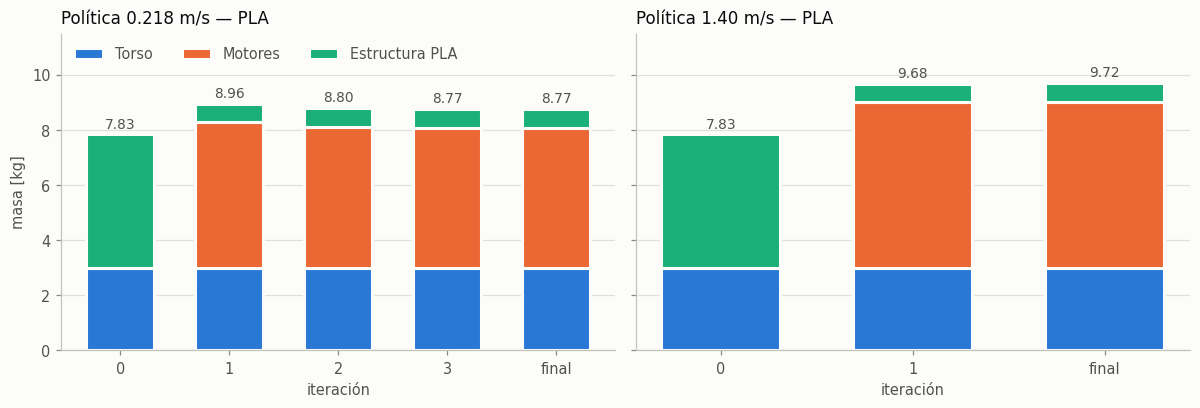

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
parts = [("torso", "Torso", SERIES[0]), ("motors", "Motores", SERIES[1]), ("structure", "Estructura PLA", SERIES[2])]
for ax, k in zip(axes, POLICIES):
    h = hist[(k, "PLA")].copy()
    mt = motors[(k, "PLA")]
    final = {"torso": 3.0, "motors": mt["mass"].sum(), "structure": h.iloc[-1]["next_total"] - 3.0 - mt["mass"].sum()}
    labels = [str(i) for i in h["iter"]] + ["final"]
    vals = {p: list(h[p]) + [final[p]] for p, _, _ in parts}
    bottom = np.zeros(len(labels))
    for p, name, col in parts:
        ax.bar(labels, vals[p], bottom=bottom, color=col, width=0.62, edgecolor=SURFACE, linewidth=2, label=name)
        bottom += np.array(vals[p])
    for x, tot in zip(labels, bottom):
        ax.text(x, tot + 0.12, f"{tot:.2f}", ha="center", va="bottom", color=INK2, fontsize=9)
    ax.set_title(f"Política {POLICIES[k]} — PLA")
    ax.set_xlabel("iteración")
    ax.grid(axis="x", visible=False)
axes[0].set_ylabel("masa [kg]")
axes[0].set_ylim(0, 11.5)
axes[0].legend(loc="upper left", ncol=3)
fig.tight_layout()

**Torque máximo por articulación en cada iteración** (PLA). Al cambiar la distribución de masa
(motores en las articulaciones, patas más livianas) los picos se reacomodan y en 1–3 iteraciones se estabilizan.

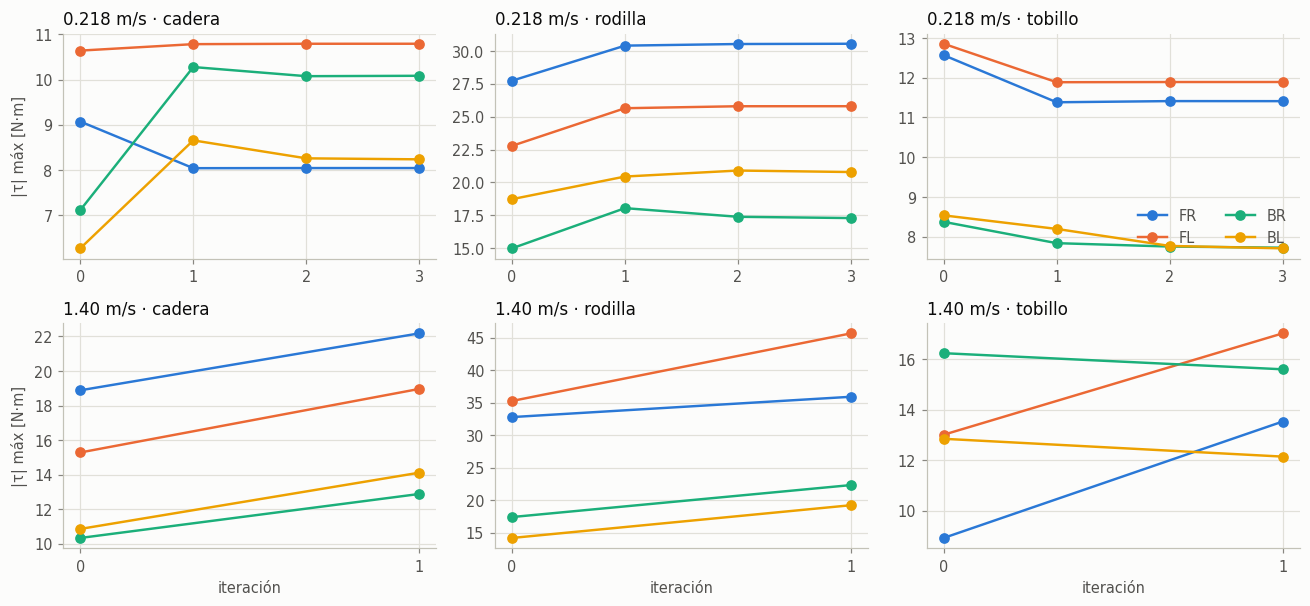

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(12, 5.6), sharex="row")
for r, k in enumerate(POLICIES):
    h = hist[(k, "PLA")]
    for c, jt in enumerate(JTYPES):
        ax = axes[r, c]
        for leg in LEGS:
            ax.plot(h["iter"], h[f"tau_max_{leg.lower()}_{jt}"], marker="o", color=LEG_COLOR[leg], label=leg)
        ax.set_title(f"{POLICIES[k]} · {JT_ES[jt]}")
        ax.set_xticks(h["iter"])
        if c == 0:
            ax.set_ylabel("|τ| máx [N·m]")
        if r == 1:
            ax.set_xlabel("iteración")
axes[0, 2].legend(ncol=2, loc="lower right")
fig.tight_layout()

## 3. Selección de motores

Cada punto gris es un actuador de la serie X del catálogo (torque pico vs velocidad máxima). Cada punto de
color es lo que **pide** una articulación: FS·|τ|máx en el eje vertical y |ω|máx en el horizontal.
Un motor sirve si queda **arriba y a la derecha** del requerimiento (además de cumplir el torque RMS).
Los motores con anillo oscuro son los seleccionados.

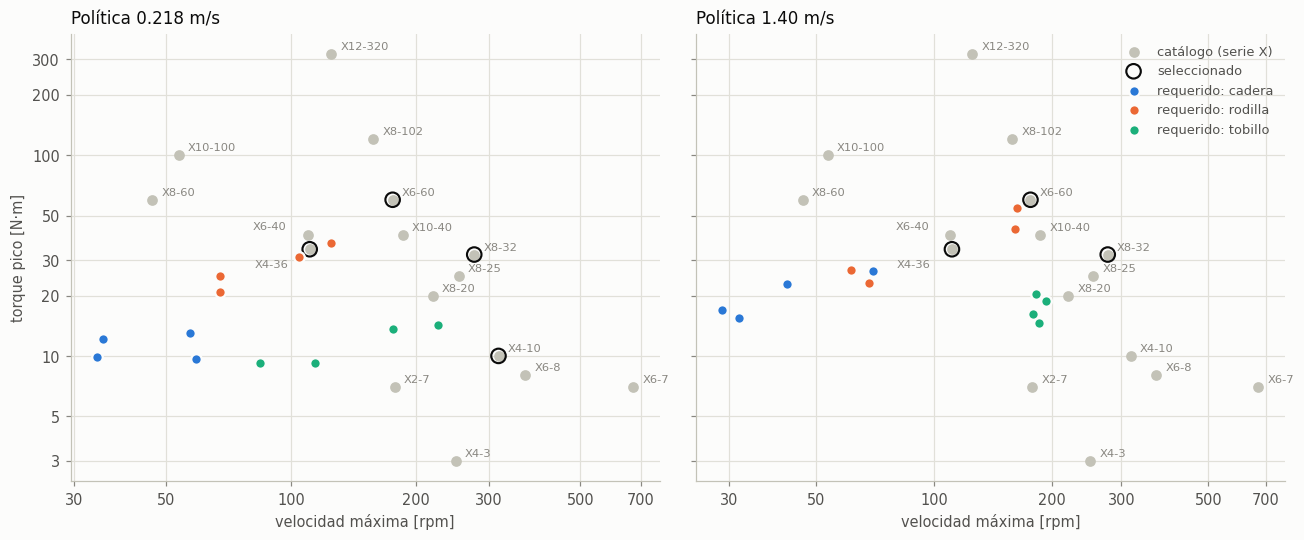

In [6]:
xs = cat[cat["series"] == "X"]
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, k in zip(axes, POLICIES):
    mt = motors[(k, "PLA")]
    chosen = set(mt["model"])
    ax.scatter(xs["speed_rpm"], xs["peak_torque_Nm"], s=36, color=AXIS, zorder=2, label="catálogo (serie X)")
    sel = xs[xs["model"].isin(chosen)]
    ax.scatter(sel["speed_rpm"], sel["peak_torque_Nm"], s=90, facecolor="none", edgecolor=INK, linewidth=1.4,
               zorder=3, label="seleccionado")
    for _, r_ in xs.iterrows():
        name = r_["model"].split()[0]
        off = {"X4-36": (-36, -12), "X6-40": (-36, 4)}.get(name, (6, 3))
        ax.annotate(name, (r_["speed_rpm"], r_["peak_torque_Nm"]), xytext=off,
                    textcoords="offset points", fontsize=7.5, color=MUTED)
    for jt in JTYPES:
        q = mt[mt["joint"].str.endswith(jt)]
        ax.scatter(q["req_speed"], q["req_peak"], s=48, color=JT_COLOR[jt], edgecolor=SURFACE, linewidth=1.5,
                   zorder=4, label=f"requerido: {JT_ES[jt]}")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xticks([30, 50, 100, 200, 300, 500, 700], ["30", "50", "100", "200", "300", "500", "700"])
    ax.set_yticks([3, 5, 10, 20, 30, 50, 100, 200, 300], ["3", "5", "10", "20", "30", "50", "100", "200", "300"])
    ax.minorticks_off()
    ax.set_xlabel("velocidad máxima [rpm]")
    ax.set_title(f"Política {POLICIES[k]}")
axes[0].set_ylabel("torque pico [N·m]")
axes[1].legend(loc="upper right", fontsize=8.5)
fig.tight_layout()

In [7]:
cols = {"joint": "Articulación", "req_peak": "FS·τmax [N·m]", "req_nominal": "FS·τRMS [N·m]", "req_speed": "ω máx [rpm]",
        "model": "Motor", "peak": "Pico [N·m]", "nominal": "Nominal [N·m]", "speed": "Vel. [rpm]",
        "mass": "Masa [kg]", "binding": "Criterio que decide"}
for k in POLICIES:
    print(f"Política {POLICIES[k]} (PLA)")
    display(motors[(k, "PLA")][list(cols)].rename(columns=cols).round(2))

Política 0.218 m/s (PLA)


,Articulación,FS·τmax [N·m],FS·τRMS [N·m],ω máx [rpm],Motor,Pico [N·m],Nominal [N·m],Vel. [rpm],Masa [kg],Criterio que decide
0,fr_hip,9.65,4.26,59.05,X4-36 36:1,34.0,10.5,111.0,0.36,speed
1,fr_knee,36.66,9.45,124.80,"X6-60 19,612:1",60.0,20.0,176.0,0.82,speed
2,fr_ankle,13.69,3.49,176.06,X8-32 9:1,32.0,8.0,277.0,0.55,speed
3,fl_hip,12.95,4.45,57.20,X4-36 36:1,34.0,10.5,111.0,0.36,speed
4,fl_knee,30.96,9.29,104.72,X4-36 36:1,34.0,10.5,111.0,0.36,speed
5,fl_ankle,14.27,3.50,227.09,X8-32 9:1,32.0,8.0,277.0,0.55,speed
6,br_hip,12.10,3.71,35.17,X4-36 36:1,34.0,10.5,111.0,0.36,peak torque
7,br_knee,20.74,8.49,67.24,X4-36 36:1,34.0,10.5,111.0,0.36,RMS torque
8,br_ankle,9.26,2.52,84.22,X4-10 12.6:1,10.0,4.0,317.0,0.33,peak torque
9,bl_hip,9.88,3.12,34.10,X4-10 12.6:1,10.0,4.0,317.0,0.33,peak torque


Política 1.40 m/s (PLA)


,Articulación,FS·τmax [N·m],FS·τRMS [N·m],ω máx [rpm],Motor,Pico [N·m],Nominal [N·m],Vel. [rpm],Masa [kg],Criterio que decide
0,fr_hip,26.61,6.77,69.78,X4-36 36:1,34.0,10.5,111.0,0.36,peak torque
1,fr_knee,43.11,10.49,160.27,"X6-60 19,612:1",60.0,20.0,176.0,0.82,speed
2,fr_ankle,16.24,4.14,178.31,X8-32 9:1,32.0,8.0,277.0,0.55,speed
3,fl_hip,22.76,6.77,42.04,X4-36 36:1,34.0,10.5,111.0,0.36,peak torque
4,fl_knee,54.81,11.73,162.86,"X6-60 19,612:1",60.0,20.0,176.0,0.82,speed
5,fl_ankle,20.44,4.26,181.52,X8-32 9:1,32.0,8.0,277.0,0.55,speed
6,br_hip,15.46,4.98,31.77,X4-36 36:1,34.0,10.5,111.0,0.36,RMS torque
7,br_knee,26.81,9.45,61.40,X4-36 36:1,34.0,10.5,111.0,0.36,RMS torque
8,br_ankle,18.73,6.04,192.91,X8-32 9:1,32.0,8.0,277.0,0.55,RMS torque
9,bl_hip,16.94,5.16,28.85,X4-36 36:1,34.0,10.5,111.0,0.36,peak torque


## 4. Punto de operación de cada motor

Cada nube son los instantes de la marcha en el plano |ω|–|τ| (política elegida abajo). El rectángulo es la
envolvente del motor seleccionado (torque pico × velocidad máxima) y la línea horizontal su torque nominal.
Cambia `POLICY` para ver la otra política.

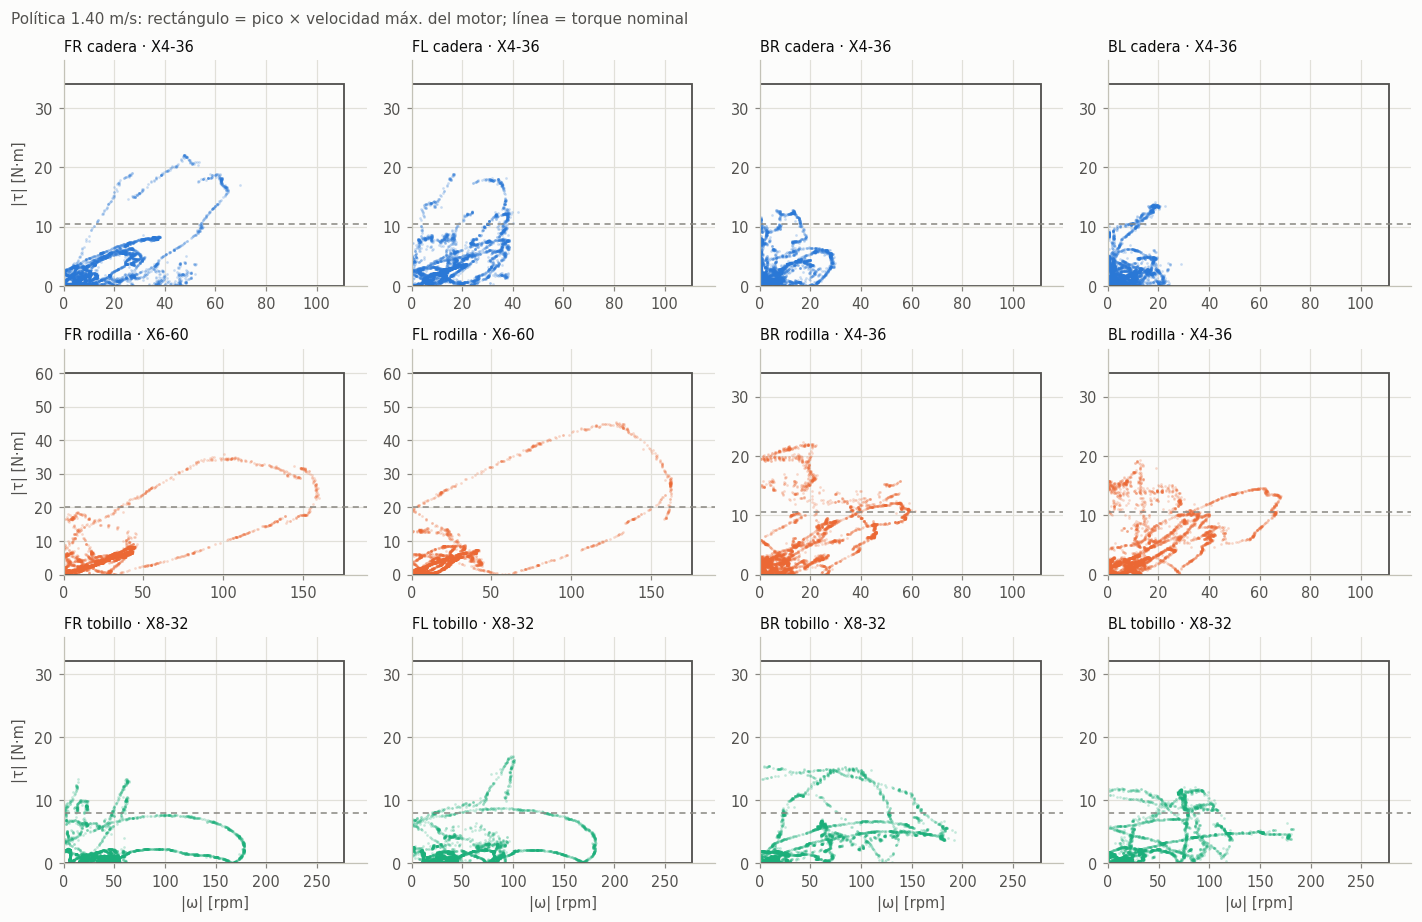

In [8]:
POLICY = "v140"          # "v0218" o "v140"
T = ts[(POLICY, "PLA")]
mt = motors[(POLICY, "PLA")].set_index("joint")
fig, axes = plt.subplots(3, 4, figsize=(13, 8.5))
for c, leg in enumerate(LEGS):
    for r, jt in enumerate(JTYPES):
        ax = axes[r, c]
        j = JOINT_NAMES.index(f"{leg.lower()}_{jt}")
        w = np.abs(T["omega"][..., j].ravel()[::2]) * 60 / (2 * np.pi)
        tau = np.abs(T["tau"][..., j].ravel()[::2])
        ax.scatter(w, tau, s=3, alpha=0.25, color=JT_COLOR[jt], linewidths=0, rasterized=True)
        m = mt.loc[f"{leg.lower()}_{jt}"]
        ax.add_patch(Rectangle((0, 0), m["speed"], m["peak"], fill=False, edgecolor=INK2, linewidth=1.2))
        ax.axhline(m["nominal"], color=MUTED, linewidth=1, linestyle=(0, (4, 3)))
        ax.set_xlim(0, max(m["speed"], w.max()) * 1.08)
        ax.set_ylim(0, max(m["peak"], tau.max()) * 1.12)
        ax.set_title(f"{leg} {JT_ES[jt]} · {m['model'].split()[0]}", fontsize=9.5)
        if c == 0:
            ax.set_ylabel("|τ| [N·m]")
        if r == 2:
            ax.set_xlabel("|ω| [rpm]")
fig.suptitle(f"Política {POLICIES[POLICY]}: rectángulo = pico × velocidad máx. del motor; línea = torque nominal",
             x=0.01, ha="left", color=INK2, fontsize=10)
fig.tight_layout()

**Velocidad de cada articulación vs el límite del motor.** Mismo arreglo de 12 paneles: la curva es la velocidad
angular de la articulación durante ~3 ciclos de marcha (primer robot) y las líneas horizontales son ± la velocidad
máxima del motor seleccionado. El título da el máximo de la marcha (todos los robots) y el % del límite que usa.

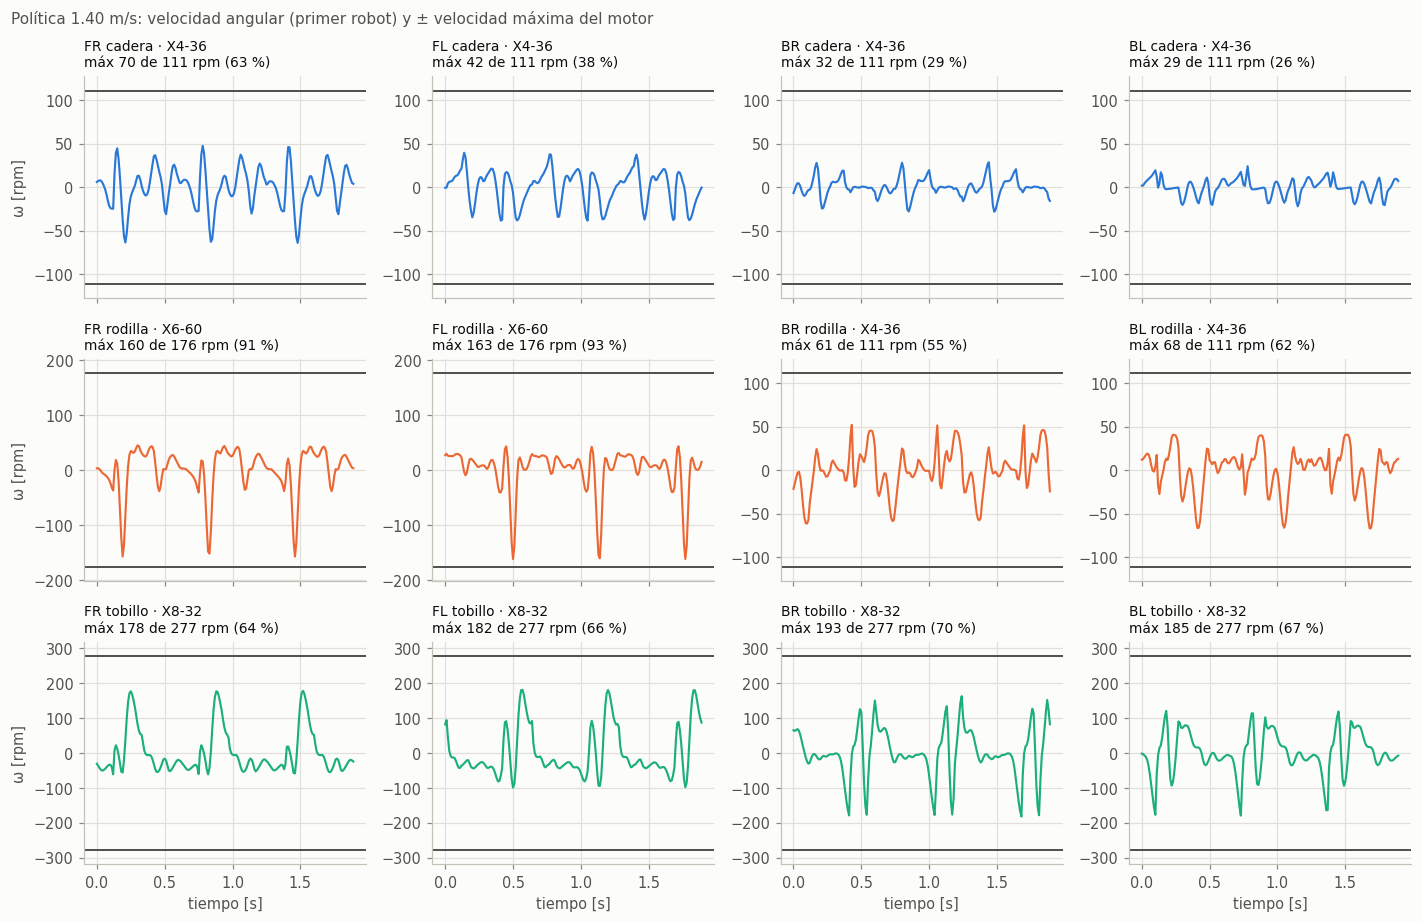

In [9]:
POLICY = "v140"          # "v0218" o "v140"
T = ts[(POLICY, "PLA")]
mt = motors[(POLICY, "PLA")].set_index("joint")
dt = float(T["dt"])
n_show = int(round(3 * 0.635 / dt))                  # ~3 ciclos de 0.635 s
t = np.arange(n_show) * dt
fig, axes = plt.subplots(3, 4, figsize=(13, 8.5), sharex=True)
for c, leg in enumerate(LEGS):
    for r, jt in enumerate(JTYPES):
        ax = axes[r, c]
        jn = f"{leg.lower()}_{jt}"
        j = JOINT_NAMES.index(jn)
        w = T["omega"][..., j] * 60 / (2 * np.pi)       # (paso, robot) en rpm, con signo
        lim = float(mt.loc[jn, "speed"])
        w_max = float(np.abs(w).max())
        ax.plot(t, w[:n_show, 0], color=JT_COLOR[jt], linewidth=1.4)
        for s_ in (1, -1):
            ax.axhline(s_ * lim, color=INK2, linewidth=1.3)
        ax.set_ylim(-1.15 * lim, 1.15 * lim)
        ax.set_title(f"{leg} {JT_ES[jt]} · {mt.loc[jn, 'model'].split()[0]}\n"
                     f"máx {w_max:.0f} de {lim:.0f} rpm ({100 * w_max / lim:.0f} %)", fontsize=9)
        if c == 0:
            ax.set_ylabel("ω [rpm]")
        if r == 2:
            ax.set_xlabel("tiempo [s]")
fig.suptitle(f"Política {POLICIES[POLICY]}: velocidad angular (primer robot) y ± velocidad máxima del motor",
             x=0.01, ha="left", color=INK2, fontsize=10)
fig.tight_layout()

**Torque de cada articulación vs límites del motor.** Mismo arreglo que el de velocidades: la curva es el torque del
motor durante ~3 ciclos de marcha (primer robot); las líneas sólidas son ± el torque pico del motor seleccionado y las
punteadas ± su torque nominal (límite continuo, se compara con el RMS). El título da el máximo y el RMS de la marcha
(todos los robots) y el % de cada límite que usan.

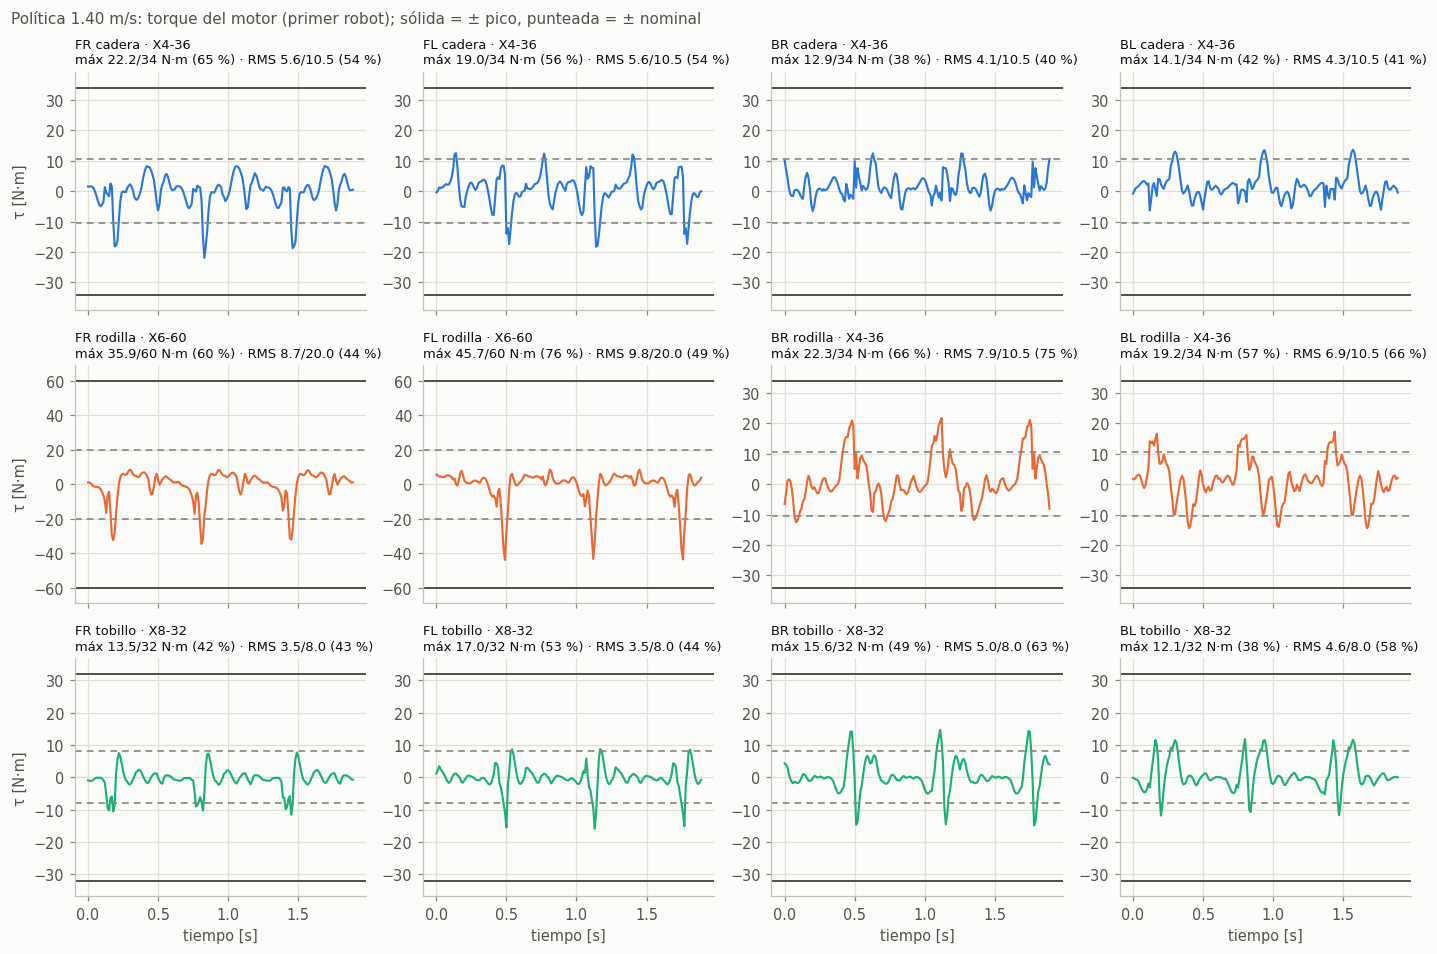

In [10]:
POLICY = "v140"          # "v0218" o "v140"
T = ts[(POLICY, "PLA")]
mt = motors[(POLICY, "PLA")].set_index("joint")
dt = float(T["dt"])
n_show = int(round(3 * 0.635 / dt))                  # ~3 ciclos de 0.635 s
t = np.arange(n_show) * dt
fig, axes = plt.subplots(3, 4, figsize=(13, 8.8), sharex=True)
for c, leg in enumerate(LEGS):
    for r, jt in enumerate(JTYPES):
        ax = axes[r, c]
        jn = f"{leg.lower()}_{jt}"
        j = JOINT_NAMES.index(jn)
        tau = T["tau"][..., j]                          # (paso, robot) en N·m, con signo
        peak, nom = float(mt.loc[jn, "peak"]), float(mt.loc[jn, "nominal"])
        t_max = float(np.abs(tau).max())
        t_rms = float(np.sqrt((tau ** 2).mean()))
        ax.plot(t, tau[:n_show, 0], color=JT_COLOR[jt], linewidth=1.4)
        for s_ in (1, -1):
            ax.axhline(s_ * peak, color=INK2, linewidth=1.3)
            ax.axhline(s_ * nom, color=MUTED, linewidth=1.1, linestyle=(0, (4, 3)))
        ax.set_ylim(-1.15 * peak, 1.15 * peak)
        ax.set_title(f"{leg} {JT_ES[jt]} · {mt.loc[jn, 'model'].split()[0]}\n"
                     f"máx {t_max:.1f}/{peak:.0f} N·m ({100 * t_max / peak:.0f} %) · "
                     f"RMS {t_rms:.1f}/{nom:.1f} ({100 * t_rms / nom:.0f} %)", fontsize=8.5)
        if c == 0:
            ax.set_ylabel("τ [N·m]")
        if r == 2:
            ax.set_xlabel("tiempo [s]")
fig.suptitle(f"Política {POLICIES[POLICY]}: torque del motor (primer robot); sólida = ± pico, punteada = ± nominal",
             x=0.01, ha="left", color=INK2, fontsize=10)
fig.tight_layout()

## 4b. Torques y velocidades vs límites de cada motor

Resumen de las 12 articulaciones con el motor seleccionado (PLA). Primero en unidades reales: la barra es lo que
exige la marcha y las marcas verticales son los límites del motor. Después todo en un solo gráfico como
**% del límite** del motor: 100 % = límite del motor; la línea punteada es el máximo permitido para el torque con
FS = 1.2 (la velocidad usa FS = 1.0, así que puede llegar al 100 %).

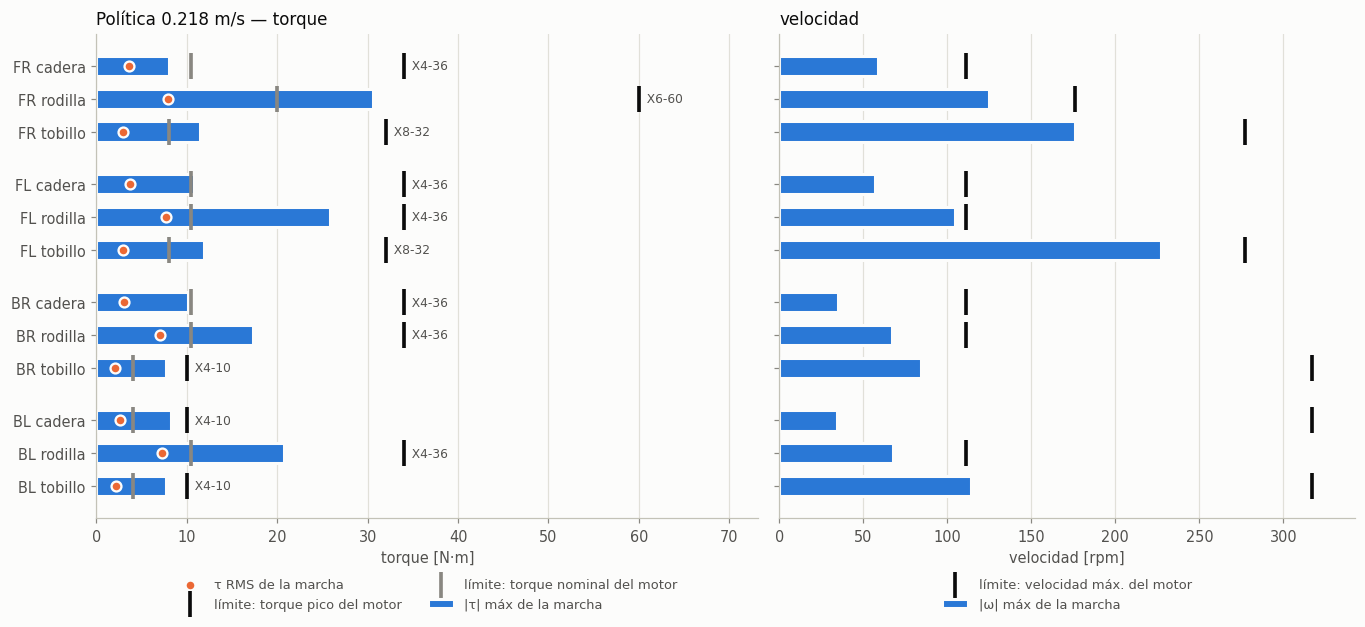

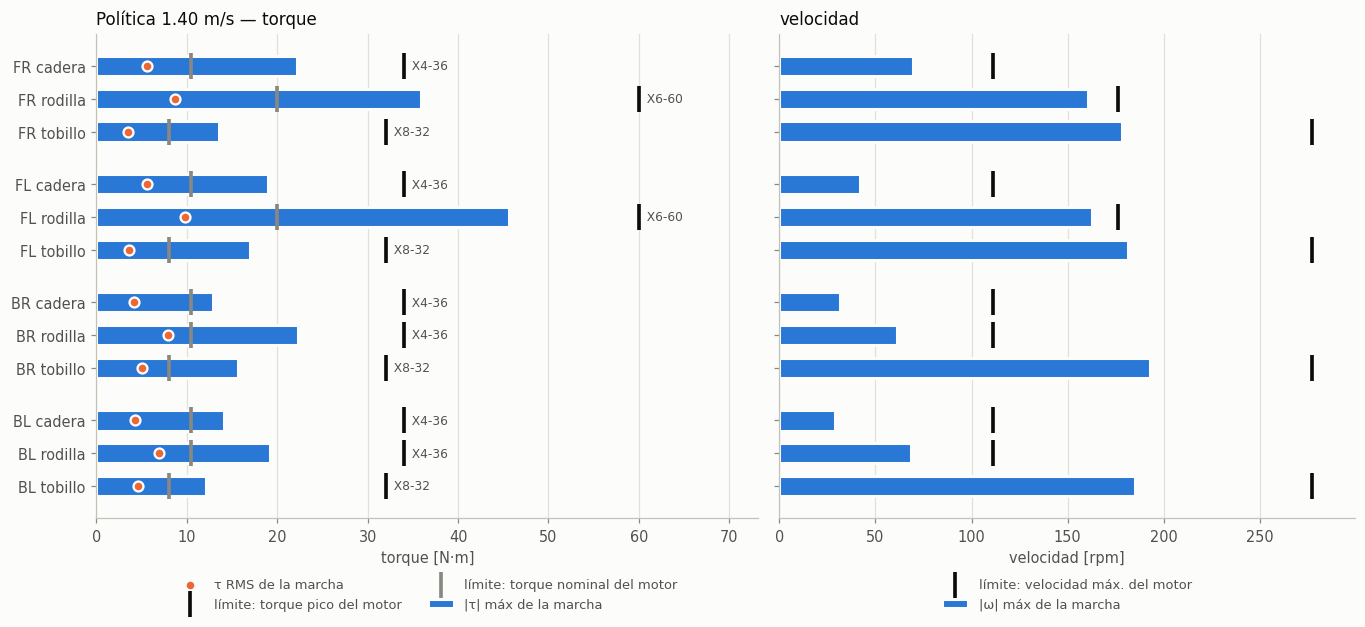

In [11]:
def joint_stats(k, m="PLA"):
    """Exigencia de la marcha (serie de tiempo final) y límites del motor seleccionado, por articulación."""
    T = ts[(k, m)]
    mt = motors[(k, m)].set_index("joint")
    rows = []
    for j, jn in enumerate(JOINT_NAMES):
        tau = T["tau"][..., j]
        w = np.abs(T["omega"][..., j]) * 60 / (2 * np.pi)
        r = mt.loc[jn]
        rows.append(dict(joint=jn, tau_max=float(np.abs(tau).max()), tau_rms=float(np.sqrt((tau ** 2).mean())),
                         w_max=float(w.max()),
                         motor=r["model"].split()[0], peak=r["peak"], nominal=r["nominal"], speed=r["speed"]))
    df = pd.DataFrame(rows).set_index("joint")
    df["uso_pico_%"] = 100 * df["tau_max"] / df["peak"]
    df["uso_rms_%"] = 100 * df["tau_rms"] / df["nominal"]
    df["uso_vel_%"] = 100 * df["w_max"] / df["speed"]
    return df

# posiciones verticales: 12 articulaciones agrupadas por pata (espacio entre patas)
Y_POS = np.arange(12) + np.repeat(np.arange(4), 3) * 0.6
Y_LAB = [f"{j[:2].upper()} {JT_ES[j[3:]]}" for j in JOINT_NAMES]

for k in POLICIES:
    df = joint_stats(k)
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.5, 5.8), sharey=True, gridspec_kw={"width_ratios": [1.15, 1]})
    # torque
    a1.barh(Y_POS, df["tau_max"], height=0.62, color=SERIES[0], edgecolor=SURFACE, linewidth=2, label="|τ| máx de la marcha")
    a1.scatter(df["tau_rms"], Y_POS, s=42, color=SERIES[1], edgecolor=SURFACE, linewidth=1.5, zorder=3, label="τ RMS de la marcha")
    a1.scatter(df["peak"], Y_POS, marker="|", s=300, color=INK, linewidths=2.4, zorder=4, label="límite: torque pico del motor")
    a1.scatter(df["nominal"], Y_POS, marker="|", s=300, color=MUTED, linewidths=2.4, zorder=4, label="límite: torque nominal del motor")
    for yi, (_, r) in zip(Y_POS, df.iterrows()):
        a1.text(r["peak"], yi, f"  {r['motor']}", va="center", fontsize=8, color=INK2)
    a1.set_xlim(0, df["peak"].max() * 1.22)
    a1.set_xlabel("torque [N·m]")
    a1.set_title(f"Política {POLICIES[k]} — torque")
    # velocidad
    a2.barh(Y_POS, df["w_max"], height=0.62, color=SERIES[0], edgecolor=SURFACE, linewidth=2, label="|ω| máx de la marcha")
    a2.scatter(df["speed"], Y_POS, marker="|", s=300, color=INK, linewidths=2.4, zorder=4, label="límite: velocidad máx. del motor")
    a2.set_xlim(0, df["speed"].max() * 1.08)
    a2.set_xlabel("velocidad [rpm]")
    a2.set_title("velocidad")
    for ax in (a1, a2):
        ax.grid(axis="y", visible=False)
    a1.set_yticks(Y_POS, Y_LAB)
    a1.invert_yaxis()
    a1.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=2, fontsize=8.5)
    a2.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=1, fontsize=8.5)
    fig.tight_layout()
    plt.show()

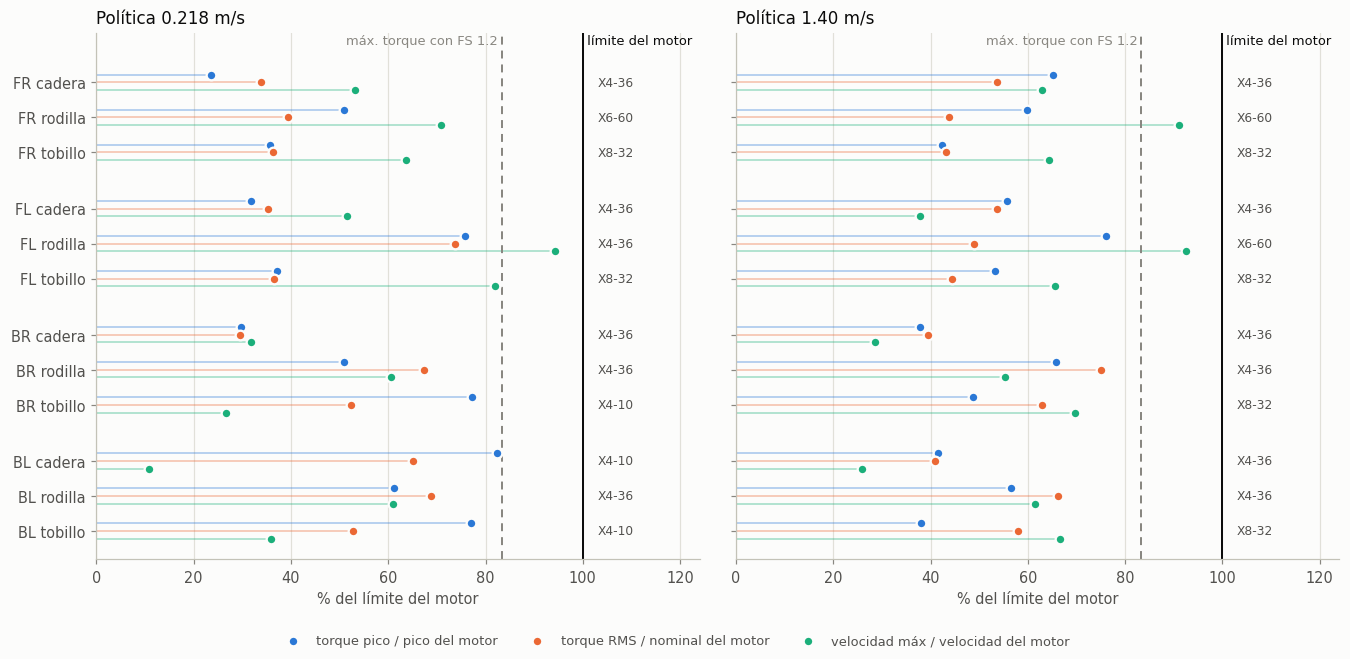

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 6), sharey=True)
crit = [("uso_pico_%", "torque pico / pico del motor", SERIES[0], -0.22),
        ("uso_rms_%", "torque RMS / nominal del motor", SERIES[1], 0.0),
        ("uso_vel_%", "velocidad máx / velocidad del motor", SERIES[2], 0.22)]
for ax, k in zip(axes, POLICIES):
    df = joint_stats(k)
    for col, lab, colr, dy in crit:
        ax.hlines(Y_POS + dy, 0, df[col], color=colr, linewidth=1.2, alpha=0.35)
        ax.scatter(df[col], Y_POS + dy, s=40, color=colr, edgecolor=SURFACE, linewidth=1.5, zorder=3, label=lab)
    ax.axvline(100, color=INK, linewidth=1.3)
    ax.axvline(100 / C.FS_TORQUE, color=MUTED, linewidth=1.3, linestyle=(0, (4, 3)))
    ax.text(100, -1.0, " límite del motor", ha="left", va="bottom", fontsize=8.5, color=INK)
    ax.text(100 / C.FS_TORQUE, -1.0, f"máx. torque con FS {C.FS_TORQUE} ", ha="right", va="bottom", fontsize=8.5, color=MUTED)
    for yi, (_, r) in zip(Y_POS, df.iterrows()):
        ax.text(103, yi, r["motor"], va="center", fontsize=8, color=INK2)
    ax.set_xlim(0, 124)
    ax.set_ylim(Y_POS.max() + 0.8, -1.4)
    ax.set_xlabel("% del límite del motor")
    ax.set_title(f"Política {POLICIES[k]}")
    ax.grid(axis="y", visible=False)
axes[0].set_yticks(Y_POS, Y_LAB)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, fontsize=8.5)
fig.tight_layout(rect=(0, 0.05, 1, 1))

In [13]:
cols = {"tau_max": "|τ| máx [N·m]", "tau_rms": "τ RMS [N·m]", "w_max": "|ω| máx [rpm]", "motor": "Motor",
        "peak": "Pico [N·m]", "nominal": "Nominal [N·m]", "speed": "Vel. máx [rpm]",
        "uso_pico_%": "Uso pico [%]", "uso_rms_%": "Uso nominal [%]", "uso_vel_%": "Uso velocidad [%]"}
tabla_motores = pd.concat({POLICIES[k]: joint_stats(k)[list(cols)].rename(columns=cols) for k in POLICIES})
tabla_motores.index.names = ["Política", "Articulación"]
tabla_motores.round(1)

|τ| máx [N·m]  τ RMS [N·m]  |ω| máx [rpm]  Motor  \
Política  Articulación                                                     
0.218 m/s fr_hip                  8.0          3.5           59.0  X4-36   
          fr_knee                30.5          7.9          124.8  X6-60   
          fr_ankle               11.4          2.9          176.1  X8-32   
          fl_hip                 10.8          3.7           57.2  X4-36   
          fl_knee                25.8          7.7          104.7  X4-36   
          fl_ankle               11.9          2.9          227.1  X8-32   
          br_hip                 10.1          3.1           35.2  X4-36   
          br_knee                17.3          7.1           67.2  X4-36   
          br_ankle                7.7          2.1           84.2  X4-10   
          bl_hip                  8.2          2.6           34.1  X4-10   
          bl_knee                20.8          7.2           67.6  X4-36   
          bl_ankle                7.7          2.1          114.0  X4-10   
1.40 m/s  fr_hip                 22.2          5.6           69.8  X4-36   
          fr_knee                35.9          8.7          160.3  X6-60   
          fr_ankle               13.5          3.5          178.3  X8-32   
          fl_hip                 19.0          5.6           42.0  X4-36   
          fl_knee                45.7          9.8          162.9  X6-60   
          fl_ankle               17.0          3.5          181.5  X8-32   
          br_hip                 12.9          4.1           31.8  X4-36   
          br_knee                22.3          7.9           61.4  X4-36   
          br_ankle               15.6          5.0          192.9  X8-32   
          bl_hip                 14.1          4.3           28.8  X4-36   
          bl_knee                19.2          6.9           68.3  X4-36   
          bl_ankle               12.1          4.6          184.8  X8-32   

                        Pico [N·m]  Nominal [N·m]  Vel. máx [rpm]  \
Política  Articulación                                              
0.218 m/s fr_hip              34.0           10.5           111.0   
          fr_knee             60.0           20.0           176.0   
          fr_ankle            32.0            8.0           277.0   
          fl_hip              34.0           10.5           111.0   
          fl_knee             34.0           10.5           111.0   
          fl_ankle            32.0            8.0           277.0   
          br_hip              34.0           10.5           111.0   
          br_knee             34.0           10.5           111.0   
          br_ankle            10.0            4.0           317.0   
          bl_hip              10.0            4.0           317.0   
          bl_knee             34.0           10.5           111.0   
          bl_ankle            10.0            4.0           317.0   
1.40 m/s  fr_hip              34.0           10.5           111.0   
          fr_knee             60.0           20.0           176.0   
          fr_ankle            32.0            8.0           277.0   
          fl_hip              34.0           10.5           111.0   
          fl_knee             60.0           20.0           176.0   
          fl_ankle            32.0            8.0           277.0   
          br_hip              34.0           10.5           111.0   
          br_knee             34.0           10.5           111.0   
          br_ankle            32.0            8.0           277.0   
          bl_hip              34.0           10.5           111.0   
          bl_knee             34.0           10.5           111.0   
          bl_ankle            32.0            8.0           277.0   

                        Uso pico [%]  Uso nominal [%]  Uso velocidad [%]  
Política  Articulación                                                    
0.218 m/s fr_hip                23.7             33.8               53.2  
          fr_knee          

## 5. Series de tiempo de torque

Un robot durante 3 s. Se separa del torque del motor la parte que se gasta contra el **amortiguamiento de la
articulación** del modelo (1.5 N·m·s/rad en cadera y rodilla) y el torque que absorbe el **tope mecánico**
(límite articular), que no pasa por el motor.

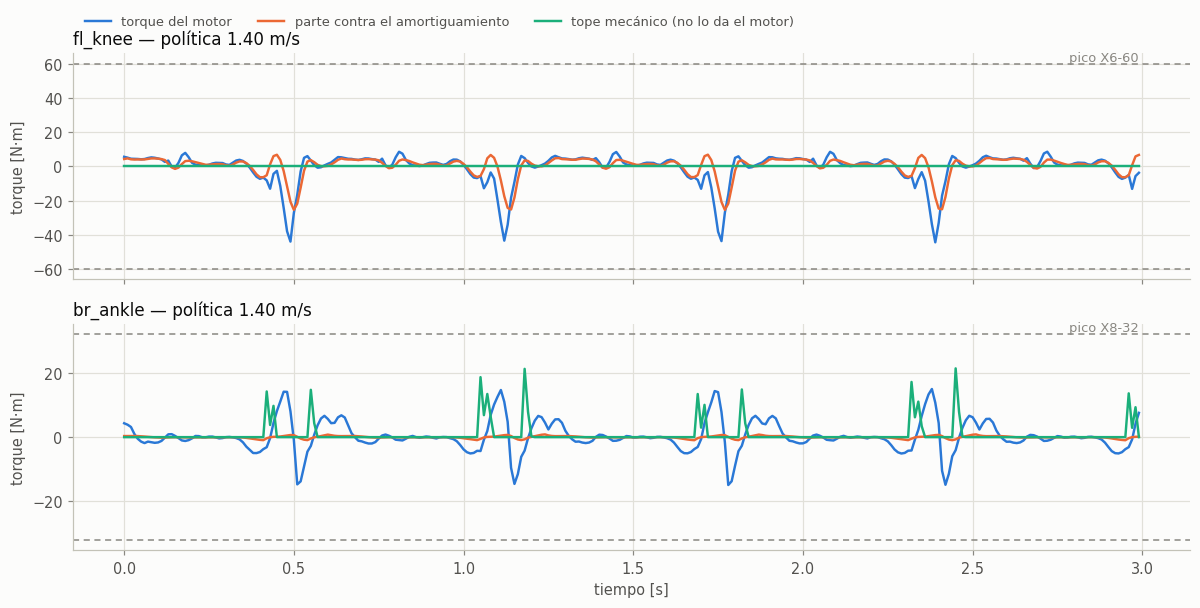

In [14]:
POLICY = "v140"
T = ts[(POLICY, "PLA")]
mt = motors[(POLICY, "PLA")].set_index("joint")
dt = float(T["dt"])
sl = (slice(0, 300), 0)                              # primer robot (índice 0), primeros 3 s
t = np.arange(300) * dt
fig, axes = plt.subplots(2, 1, figsize=(11, 5.6), sharex=True)
for ax, jn in zip(axes, ["fl_knee", "br_ankle"]):
    j = JOINT_NAMES.index(jn)
    ax.plot(t, T["tau"][sl][:, j], color=SERIES[0], label="torque del motor")
    ax.plot(t, T["tau_damp"][sl][:, j], color=SERIES[1], label="parte contra el amortiguamiento")
    ax.plot(t, T["tau_limit"][sl][:, j], color=SERIES[2], label="tope mecánico (no lo da el motor)")
    pk = mt.loc[jn, "peak"]
    for s_ in (1, -1):
        ax.axhline(s_ * pk, color=MUTED, linewidth=1, linestyle=(0, (4, 3)))
    ax.text(t[-1], pk, f" pico {mt.loc[jn, 'model'].split()[0]}", va="bottom", ha="right", color=MUTED, fontsize=8.5)
    ax.set_title(f"{jn} — política {POLICIES[POLICY]}")
    ax.set_ylabel("torque [N·m]")
axes[0].legend(loc="upper left", ncol=3, fontsize=8.5, bbox_to_anchor=(0, 1.22))
axes[1].set_xlabel("tiempo [s]")
fig.tight_layout()

## 6. Estructura

**Diámetro exterior mínimo** de cada eslabón (tubo con pared de 4 mm), criterio combinado axial + flexión +
cortante + torsión. La línea vertical es el resultado del criterio **solo axial**: en todos los eslabones el
área requerida es menor que la del tubo más pequeño posible, así que daría una barra maciza de Ø8 mm.

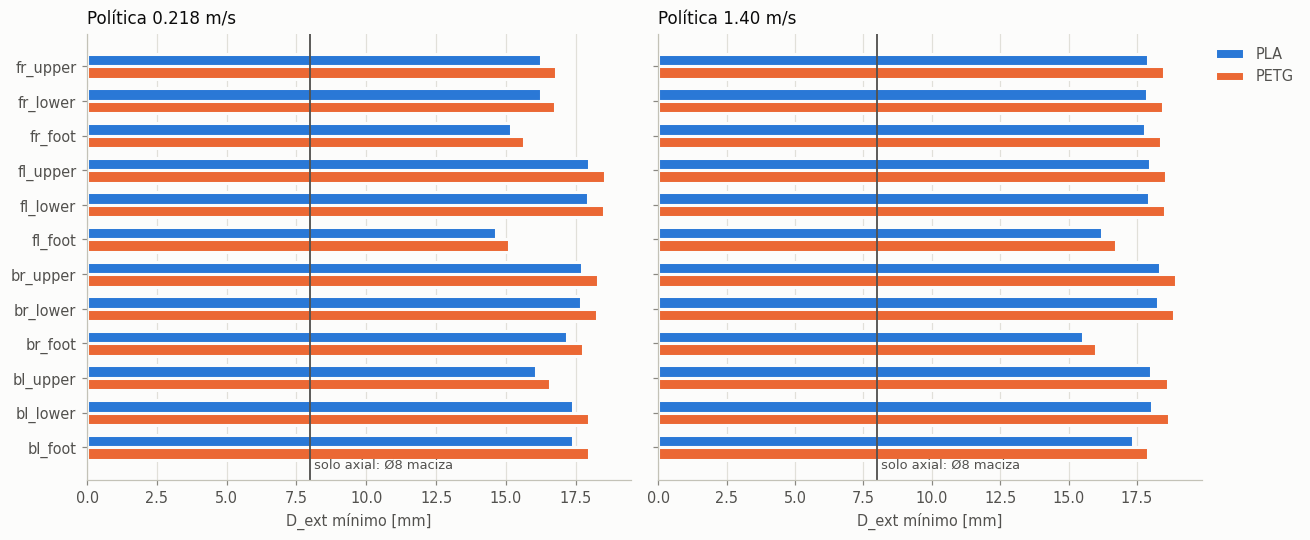

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
y = np.arange(len(LINK_NAMES))
hgt = 0.36
for ax, k in zip(axes, POLICIES):
    for i, m in enumerate(MATERIALS):
        d = 2000 * struct[(k, m)].loc[list(LINK_NAMES), "R_combined"].astype(float).values
        ax.barh(y + (i - 0.5) * hgt, d, height=hgt, color=MAT_COLOR[m], edgecolor=SURFACE, linewidth=2, label=m)
    ax.axvline(2 * C.MIN_OUTER_RADIUS_MM, color=INK2, linewidth=1.2)
    ax.text(2 * C.MIN_OUTER_RADIUS_MM, len(LINK_NAMES) - 0.3, " solo axial: Ø8 maciza", color=INK2, fontsize=8.5, va="bottom")
    ax.set_title(f"Política {POLICIES[k]}")
    ax.set_xlabel("D_ext mínimo [mm]")
    ax.grid(axis="y", visible=False)
axes[0].set_yticks(y, LINK_NAMES)
axes[0].invert_yaxis()
axes[1].legend(loc="upper left", bbox_to_anchor=(1.0, 1.0))
fig.tight_layout()

In [16]:
# Tabla de diámetros: los mismos valores de la gráfica, más diámetro interior y masa de cada tubo
t_wall = C.MIN_WALL_THICKNESS_MM
rows = {}
for link in LINK_NAMES:
    row = {("", "", "L [mm]"): round(1000 * float(struct[("v0218", "PLA")].loc[link, "length"]))}
    for k in POLICIES:
        for m in MATERIALS:
            s = struct[(k, m)].loc[link]
            d_ext = 2000 * float(s["R_combined"])
            row[(POLICIES[k], m, "D_ext [mm]")] = round(d_ext, 1)
            row[(POLICIES[k], m, "D_int [mm]")] = round(max(d_ext - 2 * t_wall, 0.0), 1)
            row[(POLICIES[k], m, "masa [g]")] = round(1000 * float(s["mass"]), 1)
    rows[link] = row
tabla = pd.DataFrame.from_dict(rows, orient="index")
tabla.columns = pd.MultiIndex.from_tuples(tabla.columns, names=["Política", "Material", ""])
total = {c: (tabla[c].sum() if c[2] == "masa [g]" else np.nan) for c in tabla.columns}
tabla.loc["TOTAL 12 tubos"] = total
print(f"Tubo hueco, pared {t_wall:.0f} mm, criterio combinado (axial + flexión + cortante + torsión). "
      f"Criterio solo axial: Ø{2*C.MIN_OUTER_RADIUS_MM:.0f} mm macizo en todos los eslabones.")
# formato: longitudes sin decimales, diámetros y masas con uno; celdas vacías en la fila de totales
fmt = {col: ("{:.0f}" if col[2] == "L [mm]" else "{:.1f}") for col in tabla.columns}
tabla.apply(lambda s: s.map(lambda v: "" if pd.isna(v) else fmt[s.name].format(v)))

Tubo hueco, pared 4 mm, criterio combinado (axial + flexión + cortante + torsión). Criterio solo axial: Ø8 mm macizo en todos los eslabones.


Política               0.218 m/s                                            \
Material                     PLA                           PETG              
               L [mm] D_ext [mm] D_int [mm] masa [g] D_ext [mm] D_int [mm]   
fr_upper          121       16.3        8.3     23.1       16.8        8.8   
fr_lower          111       16.2        8.2     21.2       16.8        8.8   
fr_foot           153       15.2        7.2     26.7       15.7        7.7   
fl_upper          121       18.0       10.0     26.3       18.5       10.5   
fl_lower          111       17.9        9.9     24.1       18.5       10.5   
fl_foot           153       14.6        6.6     25.4       15.1        7.1   
br_upper          166       17.7        9.7     35.5       18.3       10.3   
br_lower          231       17.7        9.7     49.2       18.3       10.3   
br_foot           148       17.2        9.2     30.4       17.8        9.8   
bl_upper          166       16.1        8.1     31.2       16.6        8.6   
bl_lower          231       17.4        9.4     48.3       18.0       10.0   
bl_foot           148       17.4        9.4     30.9       18.0       10.0   
TOTAL 12 tubos                                 372.3                         

Política                  1.40 m/s                                            \
Material                       PLA                           PETG              
               masa [g] D_ext [mm] D_int [mm] masa [g] D_ext [mm] D_int [mm]   
fr_upper           24.7       17.9        9.9     26.2       18.5       10.5   
fr_lower           22.6       17.9        9.9     24.0       18.4       10.4   
fr_foot            28.6       17.8        9.8     33.0       18.4       10.4   
fl_upper           28.1       18.0       10.0     26.3       18.6       10.6   
fl_lower           25.7       17.9        9.9     24.1       18.5       10.5   
fl_foot            27.2       16.2        8.2     29.2       16.7        8.7   
br_upper           37.9       18.3       10.3     37.1       18.9       10.9   
br_lower           52.6       18.3       10.3     51.3       18.9       10.9   
br_foot            32.5       15.5        7.5     26.6       16.0        8.0   
bl_upper           33.3       18.0       10.0     36.3       18.6       10.6   
bl_lower           51.5       18.1       10.1     50.6       18.7       10.7   
bl_foot            33.0       17.3        9.3     30.8       17.9        9.9   
TOTAL 12 tubos    397.7                          395.5                         

Política                 
Material                 
               masa [g]  
fr_upper           28.0  
fr_lower           25.6  
fr_foot            35.2  
fl_upper           28.1  
fl_lower           25.7  
fl_foot            31.2  
br_upper           39.6  
br_lower           54.8  
br_foot            28.4  
bl_upper           38.8  
bl_lower           54.0  
bl_foot            32.8  
TOTAL 12 tubos    422.2

**Esfuerzos en el eslabón crítico.** Descomposición del esfuerzo en el extremo proximal del eslabón con el mayor
momento flector, con el tubo ya dimensionado (PLA). La flexión domina; el axial es casi despreciable.

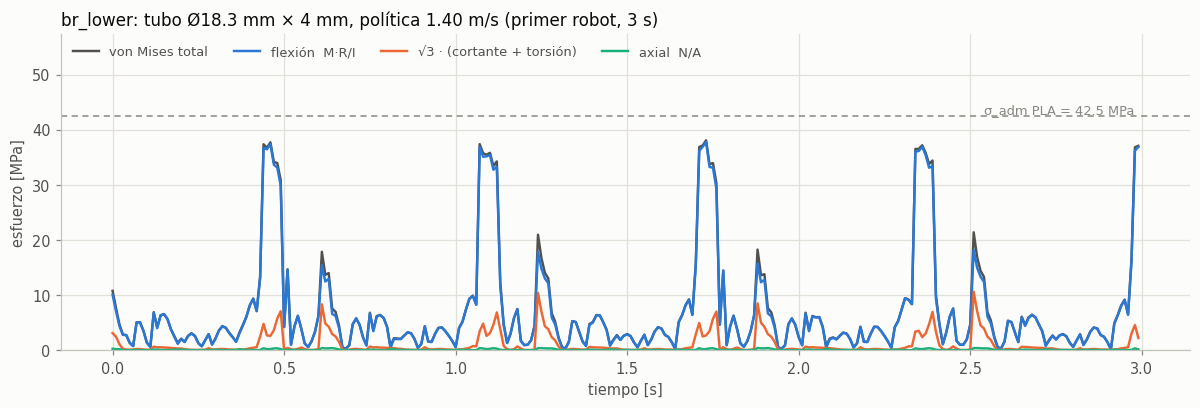

In [17]:
POLICY = "v140"
T = ts[(POLICY, "PLA")]
S = struct[(POLICY, "PLA")]
i = int(np.argmax(T["bending_Mb"].max(axis=(0, 1, 3))))
link = LINK_NAMES[i]
R = float(S.loc[link, "R_combined"]); t_w = C.MIN_WALL_THICKNESS_MM / 1000
sl = (slice(0, 300), 0)                               # primer robot, 3 s, extremo proximal
vm, s_ax, s_b, tau = ST.von_mises(R, t_w, T["axial_N"][sl][:, i, 0], T["shear_V"][sl][:, i, 0],
                                   T["bending_Mb"][sl][:, i, 0], T["torsion_T"][sl][:, i, 0])
tt = np.arange(300) * float(T["dt"])
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(tt, vm / 1e6, color=INK2, label="von Mises total")
ax.plot(tt, s_b / 1e6, color=SERIES[0], label="flexión  M·R/I")
ax.plot(tt, np.sqrt(3) * tau / 1e6, color=SERIES[1], label="√3 · (cortante + torsión)")
ax.plot(tt, s_ax / 1e6, color=SERIES[2], label="axial  N/A")
sa = float(S.loc[link, "sigma_adm"]) / 1e6
ax.axhline(sa, color=MUTED, linewidth=1, linestyle=(0, (4, 3)))
ax.text(tt[-1], sa, f"σ_adm PLA = {sa:.1f} MPa ", ha="right", va="bottom", color=MUTED, fontsize=8.5)
ax.set_title(f"{link}: tubo Ø{2000*R:.1f} mm × 4 mm, política {POLICIES[POLICY]} (primer robot, 3 s)")
ax.set_xlabel("tiempo [s]"); ax.set_ylabel("esfuerzo [MPa]")
ax.set_ylim(0, sa * 1.35)
ax.legend(loc="upper left", ncol=4, fontsize=8.5)
fig.tight_layout()

## 7. Sensibilidad al amortiguamiento articular

El modelo de la tesis tiene `damping = 1.5 N·m·s/rad` en cadera y rodilla: un regularizador para que la
simulación sea estable, no una propiedad medida de un motor. Aquí se repite el lazo completo reemplazándolo por
valores más bajos (misma marcha). Tarda ~2 min.

In [18]:
from geometry_opt.pipeline import optimize

RUN_SENSITIVITY = True
DAMPINGS = [None, 0.5, 0.1, 0.0]          # None = valor de la tesis (1.5 cadera/rodilla, 0.05 tobillo)
sens = []
if RUN_SENSITIVITY:
    for k in POLICIES:
        for dmp in DAMPINGS:
            C.JOINT_DAMPING_OVERRIDE = dmp
            r = optimize(gait[k], "PLA", cat, log=lambda *a: None)
            s = r["summary"]
            sens.append(dict(policy=k, damping=1.5 if dmp is None else dmp,
                             mass=r["final_mass"]["total"], motors=r["final_mass"]["motors"],
                             knee_front=s["tau_max"][[1, 4]].max(), knee_hind=s["tau_max"][[7, 10]].max(),
                             **{j: x["model"].split()[0] for j, x in zip(JOINT_NAMES, r["selection"])}))
    C.JOINT_DAMPING_OVERRIDE = None
sens = pd.DataFrame(sens)
sens[["policy", "damping", "mass", "motors", "knee_front", "knee_hind"]].round(2)

,policy,damping,mass,motors,knee_front,knee_hind
0,v0218,1.5,8.77,5.07,30.55,20.79
1,v0218,0.5,8.62,4.92,17.43,19.97
2,v0218,0.1,8.29,4.60,16.16,19.46
3,v0218,0.0,8.46,4.77,16.55,20.17
4,v140,1.5,9.72,6.00,45.67,22.34
5,v140,0.5,9.77,6.05,32.11,22.19
6,v140,0.1,9.17,5.46,26.00,21.82
7,v140,0.0,9.17,5.46,25.01,21.99


fr_hip fr_knee fr_ankle fl_hip fl_knee fl_ankle br_hip br_knee  \
policy damping                                                                  
v0218  1.5      X4-36   X6-60    X8-32  X4-36   X4-36    X8-32  X4-36   X4-36   
       0.5       X2-7   X8-32    X8-32  X4-10   X4-36    X8-32  X4-36   X4-36   
       0.1       X2-7   X8-32    X8-32  X4-10   X4-36    X8-32  X4-36   X4-36   
       0.0      X4-10   X8-32    X8-32  X4-36   X4-36    X8-32  X4-36   X4-36   
v140   1.5      X4-36   X6-60    X8-32  X4-36   X6-60    X8-32  X4-36   X4-36   
       0.5      X4-36   X8-32    X8-32  X4-36   X6-60    X8-32  X4-36   X4-36   
       0.1      X4-36   X8-32    X8-32  X4-36   X8-32    X8-32  X4-36   X4-36   
       0.0      X4-36   X8-32    X8-32  X4-36   X8-32    X8-32  X4-36   X4-36   

               br_ankle bl_hip bl_knee bl_ankle  
policy damping                                   
v0218  1.5        X4-10  X4-10   X4-36    X4-10  
       0.5        X4-36  X4-10   X4-36    X8-32  
       0.1        X4-10   X2-7   X4-36    X4-10  
       0.0        X4-10  X4-10   X4-36    X4-10  
v140   1.5        X8-32  X4-36   X4-36    X8-32  
       0.5        X8-25  X4-36   X4-36    X8-25  
       0.1        X8-32  X4-36   X4-36    X8-32  
       0.0        X8-32  X4-36   X4-36    X8-32

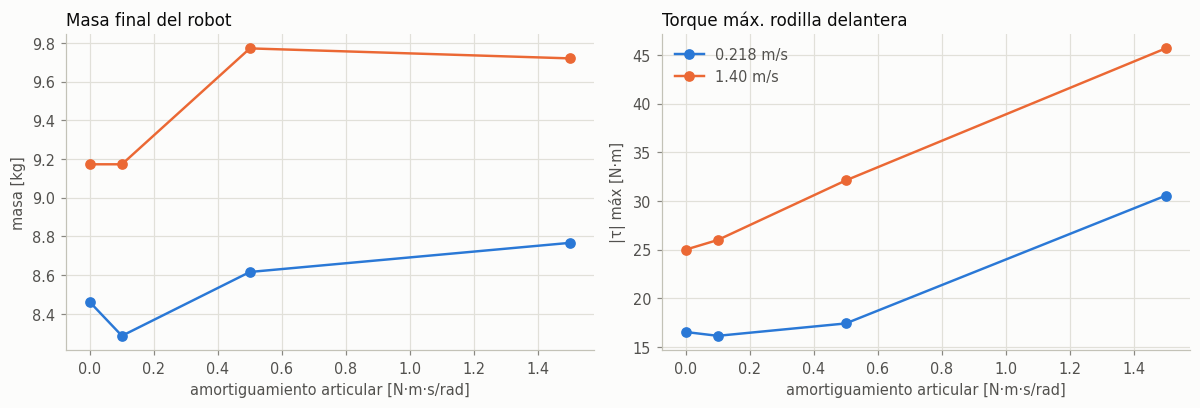

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for k in POLICIES:
    q = sens[sens["policy"] == k].sort_values("damping")
    axes[0].plot(q["damping"], q["mass"], marker="o", color=POL_COLOR[k], label=POLICIES[k])
    axes[1].plot(q["damping"], q["knee_front"], marker="o", color=POL_COLOR[k], label=POLICIES[k])
axes[0].set_title("Masa final del robot"); axes[0].set_ylabel("masa [kg]")
axes[1].set_title("Torque máx. rodilla delantera"); axes[1].set_ylabel("|τ| máx [N·m]")
for ax in axes:
    ax.set_xlabel("amortiguamiento articular [N·m·s/rad]")
axes[1].legend()
fig.tight_layout()
display(sens.set_index(["policy", "damping"])[list(JOINT_NAMES)])

## 8. Asimetría izquierda / derecha

La referencia es **simétrica por construcción** (la pata izquierda hace exactamente lo mismo que la derecha
medio ciclo después). Las políticas no: cada una aprendió pequeñas diferencias entre lados que se notan sobre
todo en los **picos** de torque. Como el motor se elige por el pico, lados distintos pueden caer en motores distintos.
Con `MISMOS_MOTORES_IZQ_DER = True` (celda de opciones) cada par usa el mismo motor, dimensionado con el lado más exigente.

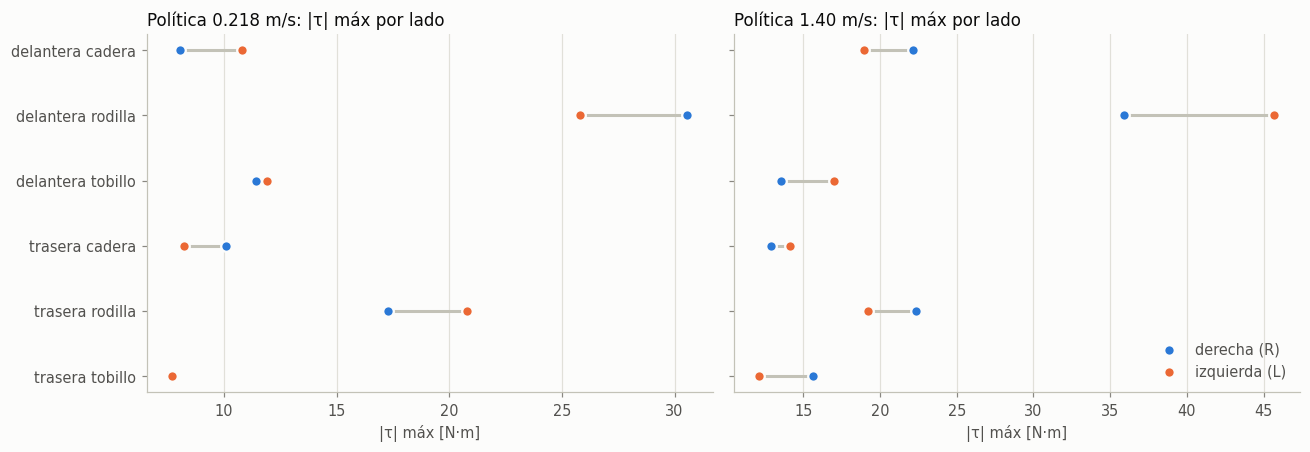

In [20]:
pairs = [("fr", "fl"), ("br", "bl")]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for ax, k in zip(axes, POLICIES):
    T = ts[(k, "PLA")]
    labels, right, left = [], [], []
    for rgt, lft in pairs:
        for jt in JTYPES:
            labels.append(f"{'delantera' if rgt[0] == 'f' else 'trasera'} {JT_ES[jt]}")
            right.append(np.abs(T["tau"][..., JOINT_NAMES.index(f"{rgt}_{jt}")]).max())
            left.append(np.abs(T["tau"][..., JOINT_NAMES.index(f"{lft}_{jt}")]).max())
    y = np.arange(len(labels))
    ax.hlines(y, np.minimum(right, left), np.maximum(right, left), color=AXIS, linewidth=2)
    ax.scatter(right, y, s=48, color=SERIES[0], edgecolor=SURFACE, linewidth=1.5, zorder=3, label="derecha (R)")
    ax.scatter(left, y, s=48, color=SERIES[1], edgecolor=SURFACE, linewidth=1.5, zorder=3, label="izquierda (L)")
    ax.set_title(f"Política {POLICIES[k]}: |τ| máx por lado")
    ax.set_xlabel("|τ| máx [N·m]")
    ax.grid(axis="y", visible=False)
axes[0].set_yticks(y, labels)
axes[0].invert_yaxis()
axes[1].legend(loc="lower right")
fig.tight_layout()

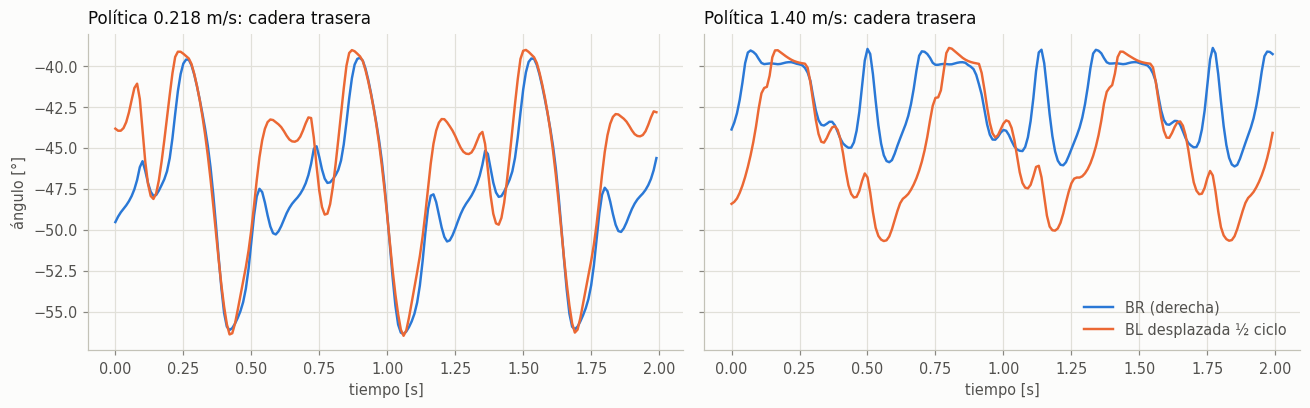

In [21]:
# Ángulo de cadera trasera: derecha vs izquierda desplazada medio ciclo (si la marcha fuera simétrica, coincidirían)
PERIOD = 0.635                                        # s, ciclo de la referencia
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, k in zip(axes, POLICIES):
    g = gait[k]; n = int(g["n_per_env"]); dt = float(g["dt"])
    half = int(round(PERIOD / 2 / dt))
    q = np.degrees(g["qpos"].reshape(n, int(g["n_envs"]), -1)[:, 0, 7:])   # primer robot
    iR, iL = JOINT_NAMES.index("br_hip"), JOINT_NAMES.index("bl_hip")
    t = np.arange(n - half) * dt
    sl = slice(0, 200)
    ax.plot(t[sl], q[half:, iR][sl], color=SERIES[0], label="BR (derecha)")
    ax.plot(t[sl], q[:-half, iL][sl], color=SERIES[1], label="BL desplazada ½ ciclo")
    ax.set_title(f"Política {POLICIES[k]}: cadera trasera")
    ax.set_xlabel("tiempo [s]")
axes[0].set_ylabel("ángulo [°]")
axes[1].legend(loc="lower right")
fig.tight_layout()